In [20]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
# from google.colab import files
# uploaded = files.upload()

# Environment check
print("OpenCV:", cv2.__version__)

OpenCV: 4.13.0


In [21]:
# Load Image

from google.colab import files
uploaded = files.upload()

Saving 44.jpg to 44 (15).jpg


Top-left pixel: [164 162 161]
Center pixel: [221 227 250]
Reloaded shape: (550, 1440, 3)
dtype: uint8


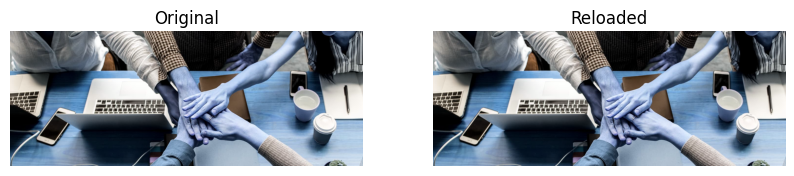

In [24]:
# Task 2.1 Pixel inspect
img = cv2.imread("44.jpg")
h, w = img.shape[:2]

print("Top-left pixel:", img[0,0])
print("Center pixel:", img[h//2, w//2])

# Each pixel in an RGB image contains three values representing the intensity of Red, Green, and Blue channels.
# For example (120,45,200) means:
# Red=120, Green=45, Blue=200.

# Task 2.2 Save and Reload
out_path = "output_saved.png"
bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
cv2.imwrite(out_path, bgr)
reloaded_bgr = cv2.imread(out_path)
reloaded_rgb = cv2.cvtColor(reloaded_bgr, cv2.COLOR_BGR2RGB)

print("Reloaded shape:", reloaded_rgb.shape)
print("dtype:", reloaded_rgb.dtype)

def show_side_by_side(img1, img2, title1="Image 1", title2="Image 2", cmap1=None, cmap2=None):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(img1, cmap=cmap1)
    plt.title(title1)
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(img2, cmap=cmap2)
    plt.title(title2)
    plt.axis('off')

    plt.show()
show_side_by_side(img, reloaded_rgb,"Original","Reloaded")

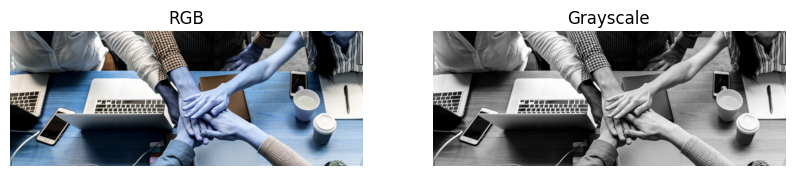

Gray shape: (550, 1440)
dtype: uint8


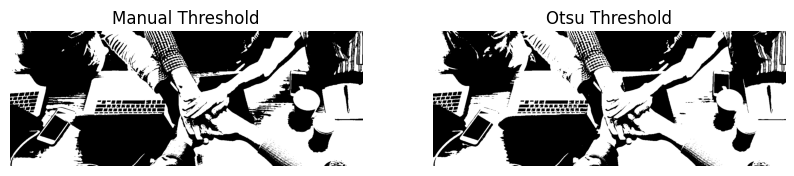

Otsu threshold: 111.0


In [25]:
# Task 3.1 Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
show_side_by_side(img, gray,"RGB","Grayscale",cmap2="gray")

print("Gray shape:", gray.shape)
print("dtype:", gray.dtype)

# Task 3.2 Binary threshold
th_manual = 128
_, binary_manual = cv2.threshold(gray, th_manual,255,cv2.THRESH_BINARY)
_, binary_otsu = cv2.threshold(gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

show_side_by_side(binary_manual,binary_otsu,
                  "Manual Threshold",
                  "Otsu Threshold",
                  cmap1="gray",
                  cmap2="gray")

print("Otsu threshold:",_)

# Manual threshold uses a fixed value (128).
# Otsu automatically calculates the optimal threshold value based on image histogram.
# Otsu usually gives better segmentation.

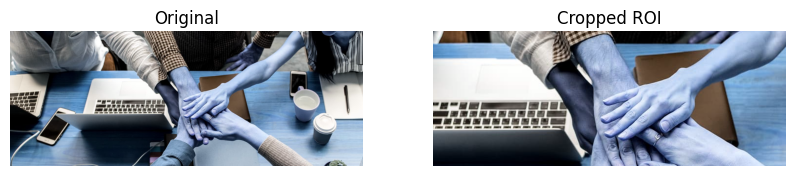

ROI shape: (275, 720, 3)


In [26]:
# Task 4.1 Cropping ROI
h,w = img.shape[:2]
x1,y1 = int(0.25*w), int(0.25*h)
x2,y2 = int(0.75*w), int(0.75*h)
roi = img[y1:y2, x1:x2].copy()
show_side_by_side(img,roi,"Original","Cropped ROI")

print("ROI shape:",roi.shape)

# Images are stored in row-major order.
# The first index represents the row (y coordinate) and the second represents the column (x coordinate).
# Therefore we use img[y,x] instead of img[x,y].

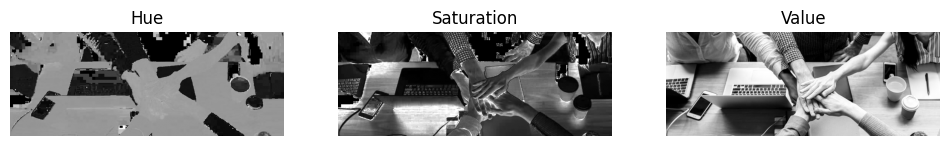

In [27]:
# Task 5.1 HSV
hsv = cv2.cvtColor(img,cv2.COLOR_RGB2HSV)

H = hsv[:,:,0]
S = hsv[:,:,1]
V = hsv[:,:,2]

plt.figure(figsize=(12,3))

plt.subplot(131)
plt.imshow(H,cmap="gray")
plt.title("Hue")
plt.axis("off")

plt.subplot(132)
plt.imshow(S,cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(133)
plt.imshow(V,cmap="gray")
plt.title("Value")
plt.axis("off")

plt.show()

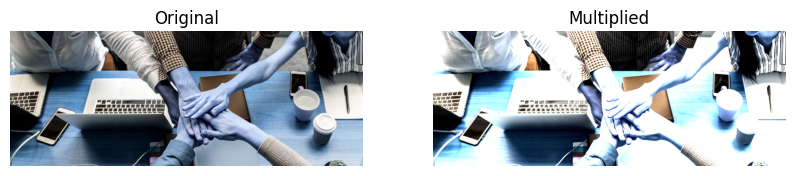

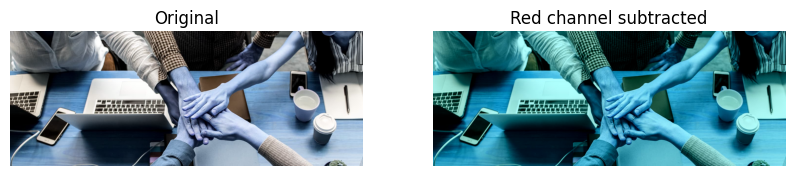

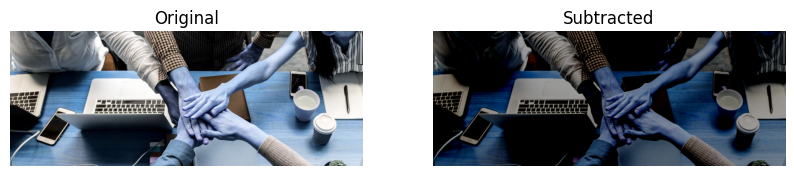

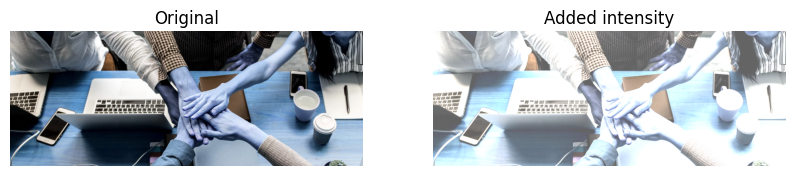

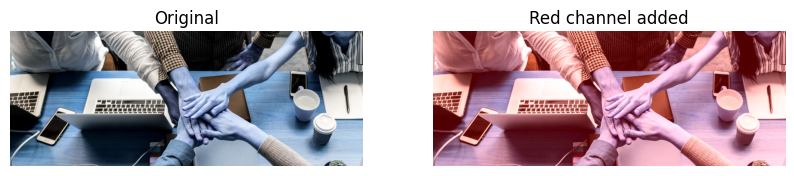

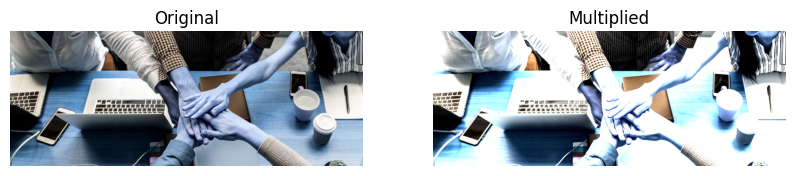

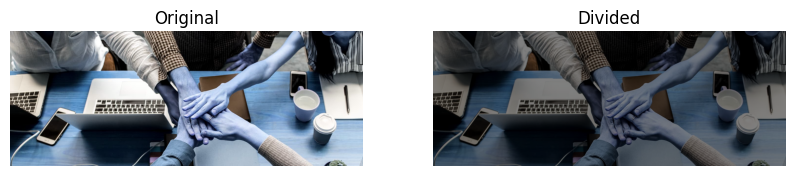

In [30]:
# Fixing error
def clip_uint8(x):
    """Clip and convert to uint8."""
    import numpy as np
    return np.clip(x, 0, 255).astype(np.uint8)
factor = 2.0
img_f = img.astype(np.float32)
img_mul = clip_uint8(img_f * factor)
show_side_by_side(img,img_mul,"Original","Multiplied")

# Task 6.2 Subtract red channel
sub_val_r = 80
img_red_only = img.copy()
img_red_only[:,:,0] = cv2.subtract(img_red_only[:,:,0],sub_val_r)

show_side_by_side(img,img_red_only,"Original","Red channel subtracted")

# Task 6.1 Subtract Intensity
sub_val = 100
img_sub = cv2.subtract(img,sub_val)
show_side_by_side(img,img_sub,"Original","Subtracted")

# Task 6.3 Add intensity
add_val = 100
img_add = cv2.add(img,add_val)
show_side_by_side(img,img_add,"Original","Added intensity")

# When add_val increases the image becomes brighter.
# This happens because pixel values increase.
# Higher intensity results in brighter pixels.

# Task 6.4 Add red channel
add_val_r = 80
img_red_only_add = img.copy()
img_red_only_add[:,:,0] = cv2.add(img_red_only_add[:,:,0],add_val_r)
show_side_by_side(img,img_red_only_add,"Original","Red channel added")

# Task 6.5 Multiply
factor = 2.0
img_f = img.astype(np.float32)
img_mul = clip_uint8(img_f * factor)
show_side_by_side(img,img_mul,"Original","Multiplied")

# Multiplying by a factor greater than 1 increases brightness and contrast.
# Multiplying by a factor less than 1 makes the image darker.

# Task 6.6 Divide
divisor = 2.0
img_f = img.astype(np.float32)
img_div = clip_uint8(img_f / divisor)
show_side_by_side(img,img_div,"Original","Divided")

# Dividing by a number greater than 1 reduces pixel values and darkens the image.
# Dividing by a number less than 1 increases pixel values and brightens the image.

In [ ]:
# In this assignment I learned the basic concepts of digital image processing using Python and OpenCV. I practiced loading and saving images, inspecting pixel values, and understanding the structure of an RGB image. I also converted images to grayscale and binary using manual thresholding and Otsu’s method. This helped me understand how image segmentation works.
# Another important task was cropping a region of interest using array slicing. This showed how images are stored as matrices and how coordinates work in row-major format (y,x). I also explored different color spaces by converting an RGB image to HSV and visualizing each channel.
# Finally, I performed basic arithmetic operations on images such as subtraction, addition, multiplication, and division. These operations helped me understand how brightness and contrast changes affect pixel intensities.
# One issue I noticed was the difference between RGB and BGR color formats when using OpenCV. It is important to convert the image before displaying it with matplotlib. Overall, this assignment helped me understand the fundamental operations used in digital image processing.